# 🌊 Rising Waters: A Machine Learning Approach to Flood Prediction

## Project Overview

This project aims to predict flood occurrence using machine learning techniques based on historical weather and environmental data. Various classification algorithms are trained and compared to identify the best-performing model for accurate flood prediction.

**Algorithms Used**
- Decision Tree
- Random Forest
- K-Nearest Neighbors (KNN)
- XGBoost

**Dataset**
Flood Risk Dataset - India

In [1]:
# ==========================================
# Import Required Libraries
# ==========================================

import warnings
warnings.filterwarnings("ignore")

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Save Models
import joblib

print("✅ Libraries Imported Successfully")

Matplotlib is building the font cache; this may take a moment.


✅ Libraries Imported Successfully


In [2]:
# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv("../dataset/flood.csv")

print("Dataset Loaded Successfully")

df.head()

Dataset Loaded Successfully


,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,3,8,6,6,4,4,6,2,3,2,...,10,7,4,2,3,4,3,2,6,0.450
1,8,4,5,7,7,9,1,5,5,4,...,9,2,6,2,1,1,9,1,3,0.475
2,3,10,4,1,7,5,4,7,4,9,...,7,4,4,8,6,1,8,3,6,0.515
3,4,4,2,7,3,4,1,4,6,4,...,4,2,6,6,8,8,6,6,10,0.520
4,3,7,5,2,5,8,5,2,7,5,...,7,6,5,3,3,4,4,3,4,0.475


In [3]:
# ==========================================
# Dataset Shape
# ==========================================

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 50000
Columns : 21


In [4]:
# ==========================================
# Dataset Information
# ==========================================

print("Shape of Dataset:", df.shape)

print("\nColumns:\n")
print(df.columns)

print("\nFirst 5 Rows:\n")
df.head()

Shape of Dataset: (50000, 21)

Columns:

Index(['MonsoonIntensity', 'TopographyDrainage', 'RiverManagement',
       'Deforestation', 'Urbanization', 'ClimateChange', 'DamsQuality',
       'Siltation', 'AgriculturalPractices', 'Encroachments',
       'IneffectiveDisasterPreparedness', 'DrainageSystems',
       'CoastalVulnerability', 'Landslides', 'Watersheds',
       'DeterioratingInfrastructure', 'PopulationScore', 'WetlandLoss',
       'InadequatePlanning', 'PoliticalFactors', 'FloodProbability'],
      dtype='str')

First 5 Rows:



,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,3,8,6,6,4,4,6,2,3,2,...,10,7,4,2,3,4,3,2,6,0.450
1,8,4,5,7,7,9,1,5,5,4,...,9,2,6,2,1,1,9,1,3,0.475
2,3,10,4,1,7,5,4,7,4,9,...,7,4,4,8,6,1,8,3,6,0.515
3,4,4,2,7,3,4,1,4,6,4,...,4,2,6,6,8,8,6,6,10,0.520
4,3,7,5,2,5,8,5,2,7,5,...,7,6,5,3,3,4,4,3,4,0.475


In [5]:
# ==========================================
# Missing Values
# ==========================================

print(df.isnull().sum())

MonsoonIntensity                   0
TopographyDrainage                 0
RiverManagement                    0
Deforestation                      0
Urbanization                       0
ClimateChange                      0
DamsQuality                        0
Siltation                          0
AgriculturalPractices              0
Encroachments                      0
IneffectiveDisasterPreparedness    0
DrainageSystems                    0
CoastalVulnerability               0
Landslides                         0
Watersheds                         0
DeterioratingInfrastructure        0
PopulationScore                    0
WetlandLoss                        0
InadequatePlanning                 0
PoliticalFactors                   0
FloodProbability                   0
dtype: int64


In [6]:
# ==========================================
# Statistical Summary
# ==========================================

df.describe()

,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000
mean,4.991480,4.984100,5.01594,5.008480,4.989060,4.988340,5.01536,4.988600,5.006120,5.006380,...,5.006060,4.999920,4.984220,4.97982,4.988200,4.984980,5.00512,4.994360,4.990520,0.499660
std,2.236834,2.246488,2.23131,2.222743,2.243159,2.226761,2.24500,2.232642,2.234588,2.241633,...,2.238107,2.247101,2.227741,2.23219,2.231134,2.238279,2.23176,2.230011,2.246075,0.050034
min,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.285000
25%,3.000000,3.000000,3.00000,3.000000,3.000000,3.000000,3.00000,3.000000,3.000000,3.000000,...,3.000000,3.000000,3.000000,3.00000,3.000000,3.000000,3.00000,3.000000,3.000000,0.465000
50%,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.00000,5.000000,5.000000,0.500000
75%,6.000000,6.000000,6.00000,6.000000,6.000000,6.000000,6.00000,6.000000,6.000000,6.000000,...,6.000000,6.000000,6.000000,6.00000,6.000000,6.000000,6.00000,6.000000,6.000000,0.535000
max,16.000000,18.000000,16.00000,17.000000,17.000000,17.000000,16.00000,16.000000,16.000000,18.000000,...,17.000000,17.000000,16.000000,16.00000,17.000000,19.000000,22.00000,16.000000,16.000000,0.725000


In [7]:
# ==========================================
# Correlation with Flood Probability
# ==========================================

corr = df.corr(numeric_only=True)

print(corr["FloodProbability"].sort_values(ascending=False))

FloodProbability                   1.000000
DeterioratingInfrastructure        0.229444
TopographyDrainage                 0.229414
RiverManagement                    0.228917
Watersheds                         0.228152
DamsQuality                        0.227467
PopulationScore                    0.226928
Siltation                          0.226544
IneffectiveDisasterPreparedness    0.225126
PoliticalFactors                   0.225009
MonsoonIntensity                   0.224081
WetlandLoss                        0.223732
InadequatePlanning                 0.223329
Landslides                         0.222991
AgriculturalPractices              0.221846
ClimateChange                      0.220986
Urbanization                       0.220867
Deforestation                      0.220237
Encroachments                      0.218259
DrainageSystems                    0.217895
CoastalVulnerability               0.215187
Name: FloodProbability, dtype: float64


In [8]:
# ==========================================
# Separate Features and Target
# ==========================================

X = df.drop("FloodProbability", axis=1)
y = df["FloodProbability"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (50000, 20)
Target Shape : (50000,)


In [9]:
print("No categorical columns found.")
print("Label Encoding is not required.")

No categorical columns found.
Label Encoding is not required.


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaling Completed")

Scaling Completed


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training :", X_train.shape)
print("Testing :", X_test.shape)

Training : (40000, 20)
Testing : (10000, 20)


In [12]:
import joblib

joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

print("Scaler Saved")

Scaler Saved


In [13]:
# ==========================================
# Import Regression Models
# ==========================================

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

print("Regression Models Imported Successfully!")

Regression Models Imported Successfully!


In [14]:
# ==========================================
# Import Regression Metrics
# ==========================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Evaluation Metrics Imported Successfully!")

Evaluation Metrics Imported Successfully!


In [15]:
# ==========================================
# Model Evaluation Function
# ==========================================

import numpy as np

def evaluate_model(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    mse = mean_squared_error(y_test, predictions)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, predictions)

    print("="*60)
    print("Model :", model.__class__.__name__)
    print("="*60)

    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R² Score : {r2:.4f}")

    return mae, mse, rmse, r2

In [16]:
# ==========================================
# Decision Tree Regressor
# ==========================================

decision_tree = DecisionTreeRegressor(
    random_state=42
)

dt_mae, dt_mse, dt_rmse, dt_r2 = evaluate_model(
    decision_tree,
    X_train,
    X_test,
    y_train,
    y_test
)

Model : DecisionTreeRegressor
MAE  : 0.0377
MSE  : 0.0023
RMSE : 0.0476
R² Score : 0.0914


In [17]:
# ==========================================
# Random Forest Regressor
# ==========================================

random_forest = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_mae, rf_mse, rf_rmse, rf_r2 = evaluate_model(
    random_forest,
    X_train,
    X_test,
    y_train,
    y_test
)

Model : RandomForestRegressor
MAE  : 0.0203
MSE  : 0.0007
RMSE : 0.0258
R² Score : 0.7334


In [18]:
# ==========================================
# XGBoost Regressor
# ==========================================

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    objective="reg:squarederror"
)

xgb_mae, xgb_mse, xgb_rmse, xgb_r2 = evaluate_model(
    xgb,
    X_train,
    X_test,
    y_train,
    y_test
)

Model : XGBRegressor
MAE  : 0.0086
MSE  : 0.0001
RMSE : 0.0110
R² Score : 0.9517


In [19]:
# ==========================================
# Model Comparison
# ==========================================

comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        dt_mae,
        rf_mae,
        xgb_mae
    ],
    "RMSE": [
        dt_rmse,
        rf_rmse,
        xgb_rmse
    ],
    "R2 Score": [
        dt_r2,
        rf_r2,
        xgb_r2
    ]
})

comparison.sort_values(
    by="R2 Score",
    ascending=False
)


,Model,MAE,RMSE,R2 Score
2,XGBoost,0.008551,0.010969,0.951689
1,Random Forest,0.020334,0.025766,0.733442
0,Decision Tree,0.037681,0.047569,0.091446


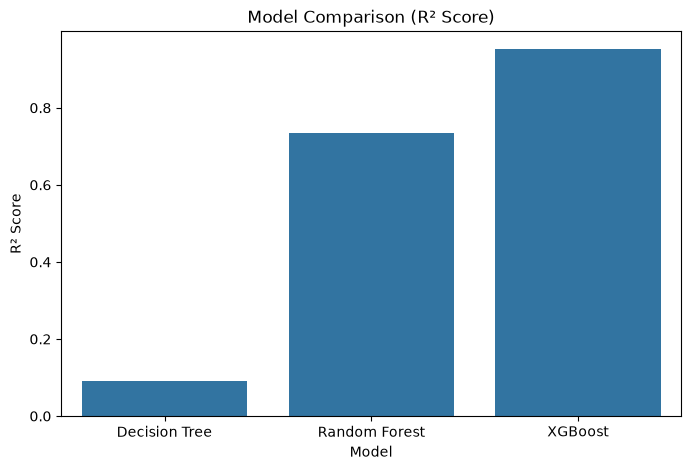

In [20]:
# ==========================================
# R² Score Comparison
# ==========================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="R2 Score"
)

plt.title("Model Comparison (R² Score)")
plt.ylabel("R² Score")

plt.show()

In [21]:
# ==========================================
# Save Best Model (XGBoost)
# ==========================================

import joblib

joblib.dump(xgb, "../models/best_model.pkl")

print("✅ Best Model Saved Successfully!")

✅ Best Model Saved Successfully!


In [22]:
import os

print(os.listdir("../models"))

['best_model.pkl', 'scaler.pkl']


In [23]:
# ==========================================
# Feature Importance
# ==========================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
13,Landslides,0.053040
15,DeterioratingInfrastructure,0.052865
19,PoliticalFactors,0.052805
17,WetlandLoss,0.052550
6,DamsQuality,0.051957
2,RiverManagement,0.051763
1,TopographyDrainage,0.051685
16,PopulationScore,0.051623
18,InadequatePlanning,0.051327
11,DrainageSystems,0.050769


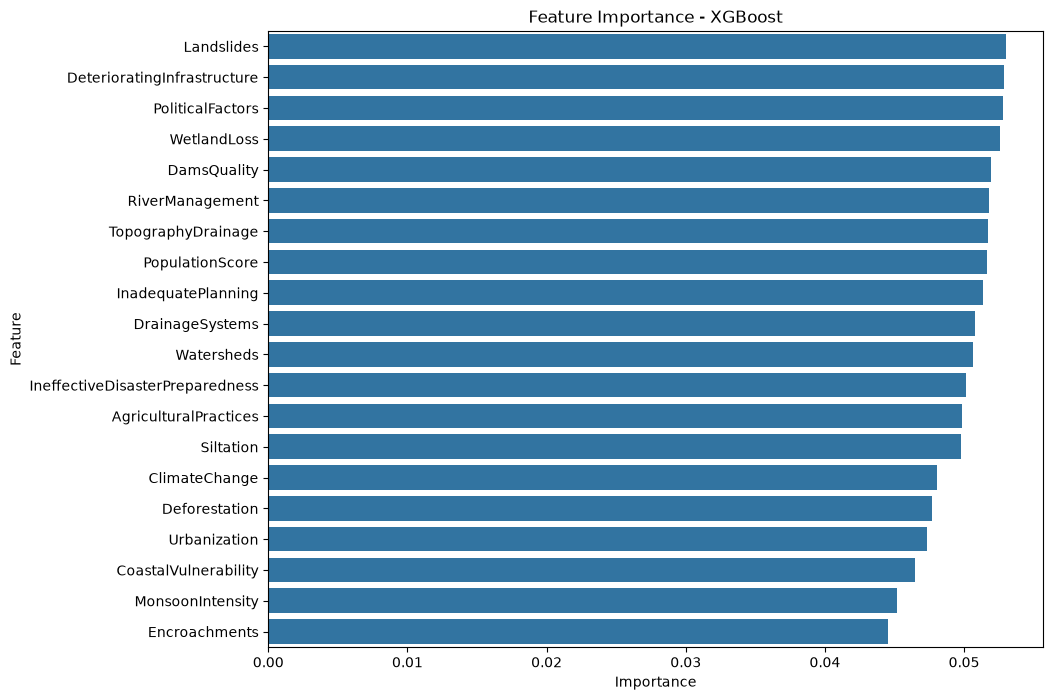

In [24]:
# ==========================================
# Feature Importance Plot
# ==========================================

plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - XGBoost")

plt.show()

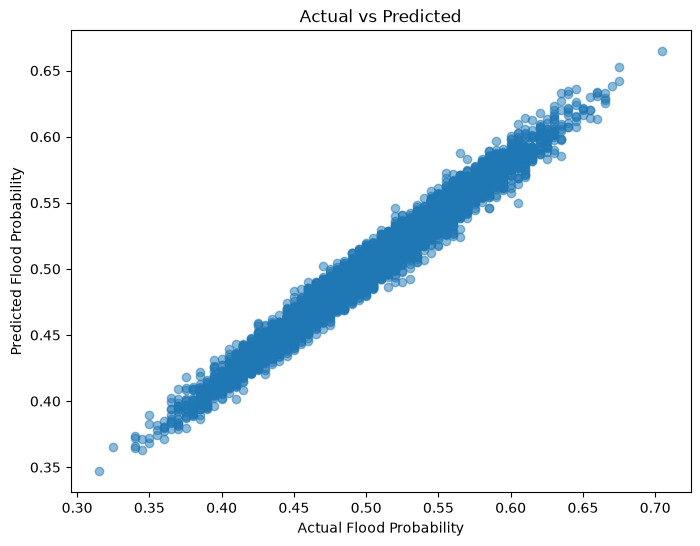

In [25]:
# ==========================================
# Actual vs Predicted
# ==========================================

predictions = xgb.predict(X_test)

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    predictions,
    alpha=0.5
)

plt.xlabel("Actual Flood Probability")
plt.ylabel("Predicted Flood Probability")
plt.title("Actual vs Predicted")

plt.show()

In [26]:
# ==========================================
# Prediction Function
# ==========================================

def predict_flood_probability(input_data):

    input_scaled = scaler.transform([input_data])

    prediction = xgb.predict(input_scaled)

    return prediction[0]

In [27]:
# ==========================================
# Test Prediction
# ==========================================

sample = X.iloc[0].values

prediction = predict_flood_probability(sample)

print(f"Predicted Flood Probability: {prediction:.4f}")
print(f"Actual Flood Probability   : {y.iloc[0]:.4f}")

Predicted Flood Probability: 0.4440
Actual Flood Probability   : 0.4500
